In [2]:
# download Dogs vs Cats dataset from Kaggle with kagglehub
# Before running this cell, open the Kaggle competition page and accept the rules.
!pip -q install kagglehub

import os
import zipfile
import kagglehub
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

base_path = kagglehub.competition_download('dogs-vs-cats')
print(f"Downloaded zip file at: {base_path}")

train_zip = os.path.join(base_path, 'train.zip')
test_zip = os.path.join(base_path, 'test1.zip')

print("Unzipping...")

os.makedirs('data', exist_ok=True)

with zipfile.ZipFile(train_zip, 'r') as zip_ref:
  zip_ref.extractall('data')

with zipfile.ZipFile(test_zip, 'r') as zip_ref:
  zip_ref.extractall('data')

print("Success?")

100%|██████████| 812M/812M [00:47<00:00, 17.9MB/s]

Extracting files...


Downloaded zip file at: /root/.cache/kagglehub/competitions/dogs-vs-cats
Unzipping...
Success?


In [3]:
# import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

np.random.seed(415)
tf.random.set_seed(415)


In [4]:
# Kaggle train images are stored in one folder: cat.0.jpg, dog.0.jpg, ...
train_dir = os.path.join('data', 'train')
all_files = sorted([f for f in os.listdir(train_dir) if f.endswith('.jpg')])

cat_files = [f for f in all_files if f.startswith('cat.')]
dog_files = [f for f in all_files if f.startswith('dog.')]

trains = [('cats', os.path.join(train_dir, f)) for f in cat_files]
trains += [('dogs', os.path.join(train_dir, f)) for f in dog_files]

In [5]:
print('total cat images used:', len(cat_files))
print('total dog images used:', len(dog_files))
print('total images used:', len(trains))

total cat images used: 12500
total dog images used: 12500
total images used: 25000


In [6]:
train_type = ['cats', 'dogs']
print(train_type)
print("Type of train dataset : ", len(train_type))

['cats', 'dogs']
Type of train dataset :  2


In [7]:
train_items, val_items = train_test_split(
    trains,
    test_size=0.2,
    random_state=415,
    stratify=[label for label, path in trains]
)

print("Train images:", len(train_items))
print("Validation images:", len(val_items))


Train images: 20000
Validation images: 5000


In [8]:
# train_items and val_items contain (label, image_path) pairs
print(train_items[:5])


[('dogs', 'data/train/dog.10684.jpg'), ('dogs', 'data/train/dog.10757.jpg'), ('dogs', 'data/train/dog.3026.jpg'), ('cats', 'data/train/cat.5154.jpg'), ('cats', 'data/train/cat.11590.jpg')]


In [9]:
# Build dataframe
trains_df = pd.DataFrame(data=trains, columns=['Pet type', 'Image'])
print(trains_df.head())
print(trains_df.tail())

  Pet type                    Image
0     cats     data/train/cat.0.jpg
1     cats     data/train/cat.1.jpg
2     cats    data/train/cat.10.jpg
3     cats   data/train/cat.100.jpg
4     cats  data/train/cat.1000.jpg
      Pet type                    Image
24995     dogs  data/train/dog.9995.jpg
24996     dogs  data/train/dog.9996.jpg
24997     dogs  data/train/dog.9997.jpg
24998     dogs  data/train/dog.9998.jpg
24999     dogs  data/train/dog.9999.jpg


In [10]:
# many of sample for each category
print("Total number of pets in the train :", len(trains_df))

Total number of pets in the train : 25000


In [11]:
pet_count = trains_df['Pet type'].value_counts()

print("print each category: ")
print(pet_count)

print each category: 
Pet type
cats    12500
dogs    12500
Name: count, dtype: int64


In [12]:
print(cat_files[:10])
print(dog_files[:10])

['cat.0.jpg', 'cat.1.jpg', 'cat.10.jpg', 'cat.100.jpg', 'cat.1000.jpg', 'cat.10000.jpg', 'cat.10001.jpg', 'cat.10002.jpg', 'cat.10003.jpg', 'cat.10004.jpg']
['dog.0.jpg', 'dog.1.jpg', 'dog.10.jpg', 'dog.100.jpg', 'dog.1000.jpg', 'dog.10000.jpg', 'dog.10001.jpg', 'dog.10002.jpg', 'dog.10003.jpg', 'dog.10004.jpg']


In [13]:
im_size = 64
batch_size = 32

label_to_index = {'cats': 0, 'dogs': 1}
index_to_label = {0: 'cats', 1: 'dogs'}

train_paths = [path for label, path in train_items]
train_y = np.array([label_to_index[label] for label, path in train_items])
val_paths = [path for label, path in val_items]
val_y = np.array([label_to_index[label] for label, path in val_items])

def load_image(path, label):
  img = tf.io.read_file(path)
  img = tf.image.decode_jpeg(img, channels=3)
  img = tf.image.resize(img, [im_size, im_size])
  img = tf.cast(img, tf.float32) / 255.0
  return img, label

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_y))
train_ds = train_ds.shuffle(1000, seed=415).map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_y))
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


In [14]:
print("Train images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Batch size:", batch_size)


Train images: 20000
Validation images: 5000
Batch size: 32


In [15]:
for sample_images, sample_labels in train_ds.take(1):
  print(sample_images.shape)
  print(sample_labels.shape)

(32, 64, 64, 3)
(32,)


In [16]:
print("Train labels sample:", train_y[:5])
print("Validation labels sample:", val_y[:5])


Train labels sample: [1 1 1 0 0]
Validation labels sample: [0 1 1 0 1]


In [17]:
print("shape of y_train:", train_y.shape)
print("shape of y_val:", val_y.shape)


shape of y_train: (20000,)
shape of y_val: (5000,)


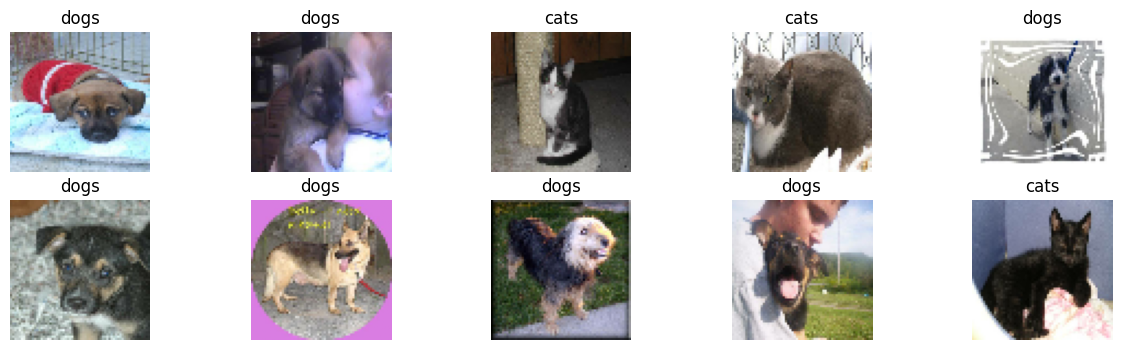

In [18]:
plt.figure(figsize=(15, 4))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(sample_images[i])
  plt.title(index_to_label[int(sample_labels[i])])
  plt.axis('off')

# **ARTIFICIAL NEURAL NETWORK**

In [19]:
model = tf.keras.models.Sequential([
    tf.keras.layers.RandomFlip("horizontal", input_shape=(im_size, im_size, 3)),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(
        256,
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(0.0005)
    ),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(2, activation='softmax')
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,146,498 (12.00 MB)

 Trainable params: 3,146,498 (12.00 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

class BestValAccuracyCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, filepath):
        super().__init__()
        self.filepath = filepath
        self.best = -np.inf

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_accuracy = logs.get('val_accuracy')
        if val_accuracy is not None and val_accuracy > self.best:
            self.best = val_accuracy
            self.model.save(self.filepath)
            print(f"\nEpoch {epoch + 1}: val_accuracy improved to {val_accuracy:.4f}. Updated {self.filepath}")

checkpoint = BestValAccuracyCheckpoint('best_ann_model.keras')

history = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=[reduce_lr, checkpoint]
)


Epoch 1/30
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5358 - loss: 0.9530
Epoch 1: val_accuracy improved to 0.5658. Updated best_ann_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - accuracy: 0.5511 - loss: 0.8947 - val_accuracy: 0.5658 - val_loss: 0.8457 - learning_rate: 1.0000e-04
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5885 - loss: 0.8251
Epoch 2: val_accuracy improved to 0.5938. Updated best_ann_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 31ms/step - accuracy: 0.5824 - loss: 0.8156 - val_accuracy: 0.5938 - val_loss: 0.7938 - learning_rate: 1.0000e-04
Epoch 3/30
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5922 - loss: 0.7820
Epoch 3: val_accuracy improved to 0.5984. Updated best_ann_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.5918 - loss: 0.7734 - val_accuracy: 0.5984 - val_loss: 0.7564 - learning_rate: 1.0000e-04
Epoch 4/30
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6018 - loss: 0.746

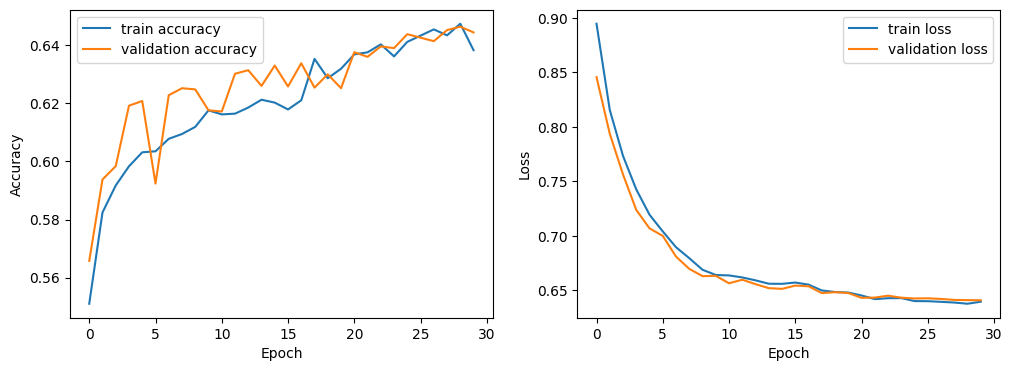

In [22]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [23]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

best_model = tf.keras.models.load_model('best_ann_model.keras')

val_loss, val_acc = best_model.evaluate(val_ds)
print("Best validation accuracy:", val_acc)
print("Best validation loss:", val_loss)

y_pred = best_model.predict(val_ds)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report:")
print(classification_report(val_y, y_pred_classes, target_names=['cats', 'dogs']))


157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.6464 - loss: 0.6410
Best validation accuracy: 0.646399974822998
Best validation loss: 0.6410443186759949
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step
Classification Report:
              precision    recall  f1-score   support

        cats       0.64      0.68      0.66      2500
        dogs       0.66      0.61      0.63      2500

    accuracy                           0.65      5000
   macro avg       0.65      0.65      0.65      5000
weighted avg       0.65      0.65      0.65      5000



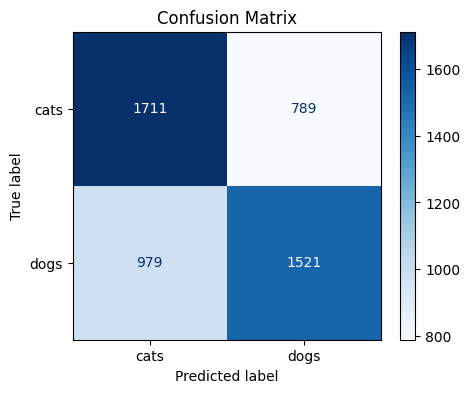

In [24]:
cm = confusion_matrix(val_y, y_pred_classes)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['cats', 'dogs']
)
disp.plot(
    cmap=plt.cm.Blues,
    values_format='d',
    ax=ax,
    colorbar=True
)
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
plt.show()
